# House Price Prediction with Random Forest

This notebook demonstrates house price prediction using Random Forest Regressor.
We will load a house price dataset, preprocess the features, train the model,
and evaluate its performance.

## Import Required Libraries

In [1]:
# pandas is used for data handling (tables)
import pandas as pd

# numpy is used for numerical calculations
import numpy as np

# matplotlib is used for plotting graphs
import matplotlib.pyplot as plt

# train_test_split is used to split data into training and testing
from sklearn.model_selection import train_test_split

# StandardScaler is used to scale numeric values
# OneHotEncoder is used to convert text data into numbers
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# SimpleImputer is used to fill missing values
from sklearn.impute import SimpleImputer

# ColumnTransformer applies different processing to different columns
from sklearn.compose import ColumnTransformer

# Pipeline helps to combine all steps in one flow
from sklearn.pipeline import Pipeline

# Evaluation metrics for checking model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error

# RandomForestRegressor is the machine learning model used for prediction
from sklearn.ensemble import RandomForestRegressor

## Load Dataset

In [2]:
file_path = 'House Price Prediction Dataset.csv'

# Try loading dataset from given path
try:
    df = pd.read_csv(file_path)
except:
    # If first path fails, try alternative path
    df = pd.read_csv('House Price Prediction Dataset.csv')

## Dataset Overview

In [3]:
# Show first 5 rows of dataset
print("\nFirst 5 Rows of Dataset:\n")
print(df.head())


First 5 Rows of Dataset:

   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  


In [4]:
# Show dataset information (data types, missing values, etc.)
print("\nDataset Information:\n")
print(df.info())


Dataset Information:

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 184.3 KB
None


In [5]:
# Show missing values in each column
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


## Data Cleaning

In [6]:
# If dataset has 'Id' column, remove it
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)
    print("\nId column removed successfully.")


Id column removed successfully.


## Select Target Column

In [7]:
# Possible names for target column
possible_targets = ['Price', 'price', 'SalePrice', 'saleprice']

target_column = None

# Find correct target column from dataset
for col in possible_targets:
    if col in df.columns:
        target_column = col
        break

# If target column not found, show error
if target_column is None:
    raise Exception(
        "Target column not found. Rename your target column to Price."
    )

print(f"\nTarget Column: {target_column}")


Target Column: Price


## Split Features and Target

In [8]:
# X = input features (all columns except target)
X = df.drop(target_column, axis=1)

# y = output column (price we want to predict)
y = df[target_column]

## Identify Numeric and Categorical Columns

In [9]:
# Numeric columns (numbers like area, rooms, etc.)
numeric_features = X.select_dtypes(include=np.number).columns

# Categorical columns (text like location, type, etc.)
categorical_features = X.select_dtypes(exclude=np.number).columns

print("\nNumeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


Numeric Features:
Index(['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt'], dtype='str')

Categorical Features:
Index(['Location', 'Condition', 'Garage'], dtype='str')


## Data Preprocessing Pipelines

Set up separate preprocessing pipelines for numeric and categorical data

In [10]:
# Numeric data processing steps
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # fill missing values with mean
    ('scaler', StandardScaler())  # scale data to improve model performance
])

# Categorical data processing steps
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # fill missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # convert text into numbers
])

# Combine numeric + categorical processing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## Build Machine Learning Model

Random Forest with 200 trees for better accuracy

In [11]:
# Random Forest is used for better accuracy on real-world data
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,  # number of trees in forest
        random_state=42
    ))
])

## Split Data into Training and Testing

In [12]:
# 80% training data, 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train the Model

In [13]:
model.fit(X_train, y_train)

print("\nModel Training Completed Successfully!")


Model Training Completed Successfully!


## Make Predictions

In [14]:
y_pred = model.predict(X_test)

## Model Evaluation

In [15]:
# Mean Absolute Error (average error)
mae = mean_absolute_error(y_test, y_pred)

# Root Mean Squared Error (penalizes big errors more)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nModel Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


Model Evaluation:
Mean Absolute Error (MAE): 253351.55
Root Mean Squared Error (RMSE): 293288.86


## Compare Actual vs Predicted Values

In [16]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

print("\nActual vs Predicted Prices:\n")
print(comparison.head(10))


Actual vs Predicted Prices:

   Actual Price  Predicted Price
0        514764       666526.165
1        694256       496797.115
2         66375       532711.945
3        650243       486757.235
4        223285       503901.525
5        468127       556145.300
6        513002       510312.175
7        911525       600832.835
8        723265       615250.155
9        339416       649645.930


## Visualization (Actual vs Predicted)

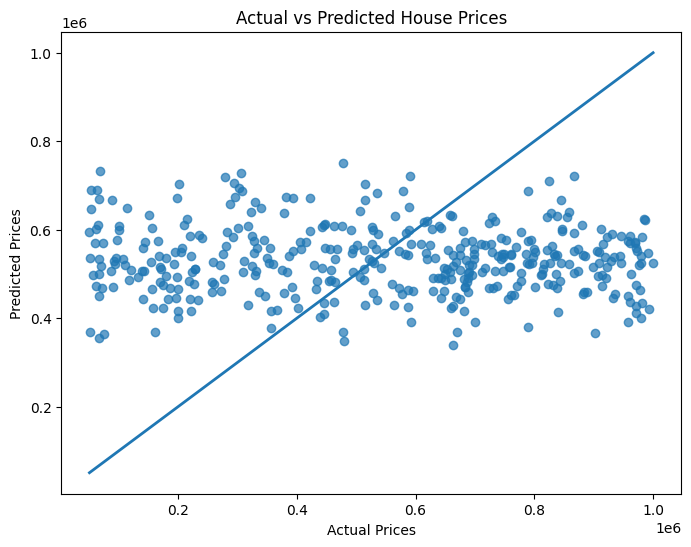

In [17]:
plt.figure(figsize=(8, 6))

# Scatter plot to compare results
plt.scatter(y_test, y_pred, alpha=0.7)

# Perfect prediction line (ideal case)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linewidth=2
)

# Labels and title
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

# Show graph
plt.show()